In [37]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import yaml
from dataset import get_real_batch_groove

In [38]:
import torch
import sys
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from model import PQC

In [39]:
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
})

with open("./config.yaml", "r") as f:
    config = yaml.safe_load(f)

epochs = config["epochs"]
save_epoch = config["save_epoch"]
accuracy_file = config["accuracy_file"]
loss_dis_file = config["loss_dis_file"]
loss_gen_file = config["loss_gen_file"]
kl_div_file = config["kl_div_file"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
epoch_list = list(range(1, epochs+1, save_epoch))

Device: cuda


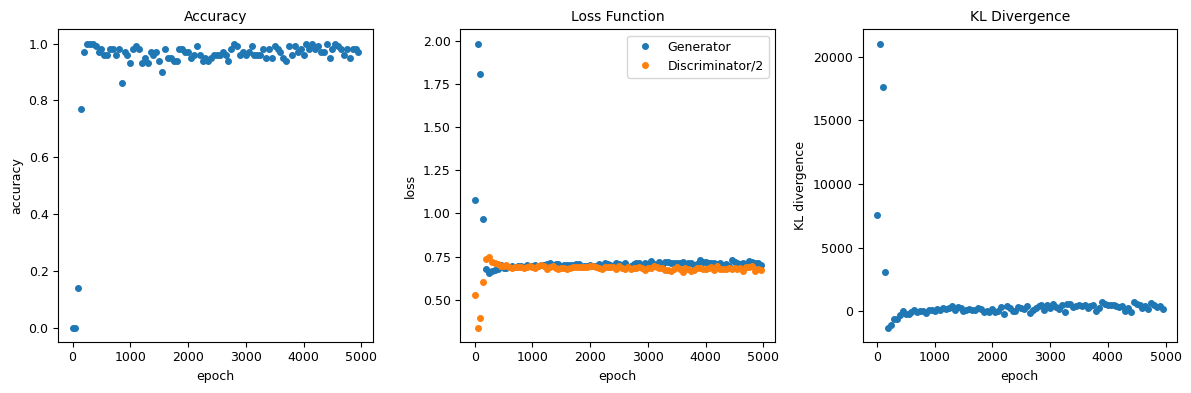

In [40]:
output_dir = "./experiment/RideN16_mps_L3_V2"

epoch_list = epoch_list[:100]

# Load data
accuracy_list = np.load(f"{output_dir}/{accuracy_file}")
loss_dis_list = np.load(f"{output_dir}/{loss_dis_file}")
loss_gen_list = np.load(f"{output_dir}/{loss_gen_file}")
kl_div_list = np.load(f"{output_dir}/{kl_div_file}")

half_loss_dis_list = [loss_dis / 2 for loss_dis in loss_dis_list]

# Plot (横に3つ)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Accuracy
axes[0].plot(epoch_list, accuracy_list, "o", markersize=4)
axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("accuracy")

# Loss function
axes[1].plot(epoch_list, loss_gen_list, "o", markersize=4, label="Generator")
axes[1].plot(epoch_list, half_loss_dis_list, "o", markersize=4, label="Discriminator/2")
axes[1].set_title("Loss Function")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].legend()

# KL divergence
axes[2].plot(epoch_list, kl_div_list, "o", markersize=4)
axes[2].set_title("KL Divergence")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("KL divergence")

plt.tight_layout()
plt.show()

In [41]:
with open(f"{output_dir}/param.yaml", "r") as f:
    param = yaml.safe_load(f)
with open(f"config.yaml", "r") as f:
    config = yaml.safe_load(f)

length = param["length"]
# size = length**2
size = length
n_layers = param["n_layers"]
bs_dis = param["bs_dis"]
bs_gen = 10000 # param["bs_gen"]
lr_dis = param["lr_dis"]
lr_gen = param["lr_gen"]
features = param["features"]
d_steps = param["d_steps"]
g_steps = param["g_steps"]
drums = param["drums"]  # Add this line to get the drums parameter
epochs = config["epochs"]
save_epoch = config["save_epoch"]
log_epoch = config["log_epoch"]
epsilon = config["epsilon"]
logfile = config["logfile"]
accuracy_file = config["accuracy_file"]
loss_dis_file = config["loss_dis_file"]
loss_gen_file = config["loss_gen_file"]
kl_div_file = config["kl_div_file"]
theta_val_file = config["theta_val_file"]
device = torch.device("cuda")
is_tty = sys.stdout.isatty()

on_mps = param.get("on_mps", False)
if on_mps:
    v_mps = param["v_mps"]
    pqc = PQC(n_layers, size, bs_dis, bs_gen, lr_gen, device, on_mps, v_mps)
else:
    pqc = PQC(n_layers, size, bs_dis, bs_gen, lr_gen, device)

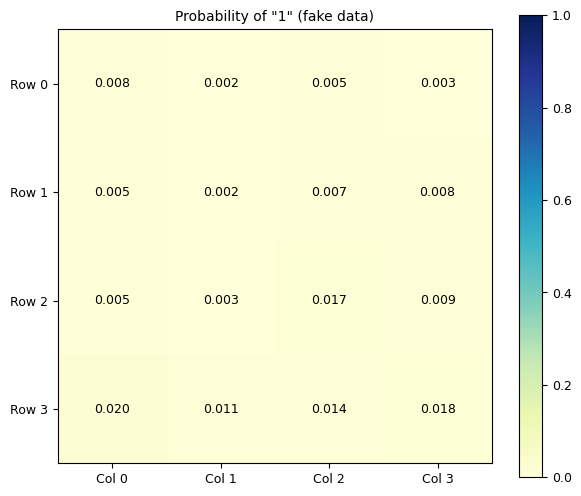

In [42]:
theta_val = np.load(f"{output_dir}/theta_val.npy")
fake_data_list = pqc.run(params=theta_val[-1], mode="G")

# 各要素（16箇所）で1が立つ確率（平均値）を計算
probabilities = np.mean(fake_data_list, axis=0)

# 16要素を 4x4 の行列に整形
heatmap_data_fake = probabilities.reshape(4, 4)

# プロット (Matplotlib の imshow を使用)
plt.figure(figsize=(7, 6))
im = plt.imshow(heatmap_data_fake, cmap='YlGnBu', vmin=0, vmax=1)

# 数値をセル内に表示
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{heatmap_data_fake[i, j]:.3f}', 
                 ha='center', va='center', color='black')

plt.colorbar(im)
plt.title('Probability of "1" (fake data)')
plt.xticks(range(4), [f'Col {i}' for i in range(4)])
plt.yticks(range(4), [f'Row {i}' for i in range(4)])
plt.show()

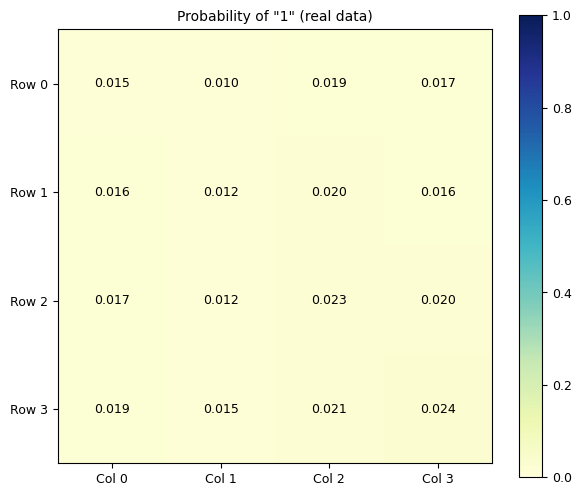

In [43]:
data_dir = '/home/spm23/groove/onehot_data'
real_data_list = get_real_batch_groove(10000, data_dir, drums=drums)
probabilities2 = np.mean(real_data_list, axis=0)

# 16要素を 4x4 の行列に整形
heatmap_data_real = probabilities2.reshape(4, 4)

# プロット (Matplotlib の imshow を使用)
plt.figure(figsize=(7, 6))
im = plt.imshow(heatmap_data_real, cmap='YlGnBu', vmin=0, vmax=1)

# 数値をセル内に表示
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{heatmap_data_real[i, j]:.3f}', 
                 ha='center', va='center', color='black')

plt.colorbar(im)
plt.title('Probability of "1" (real data)')
plt.xticks(range(4), [f'Col {i}' for i in range(4)])
plt.yticks(range(4), [f'Row {i}' for i in range(4)])
plt.show()

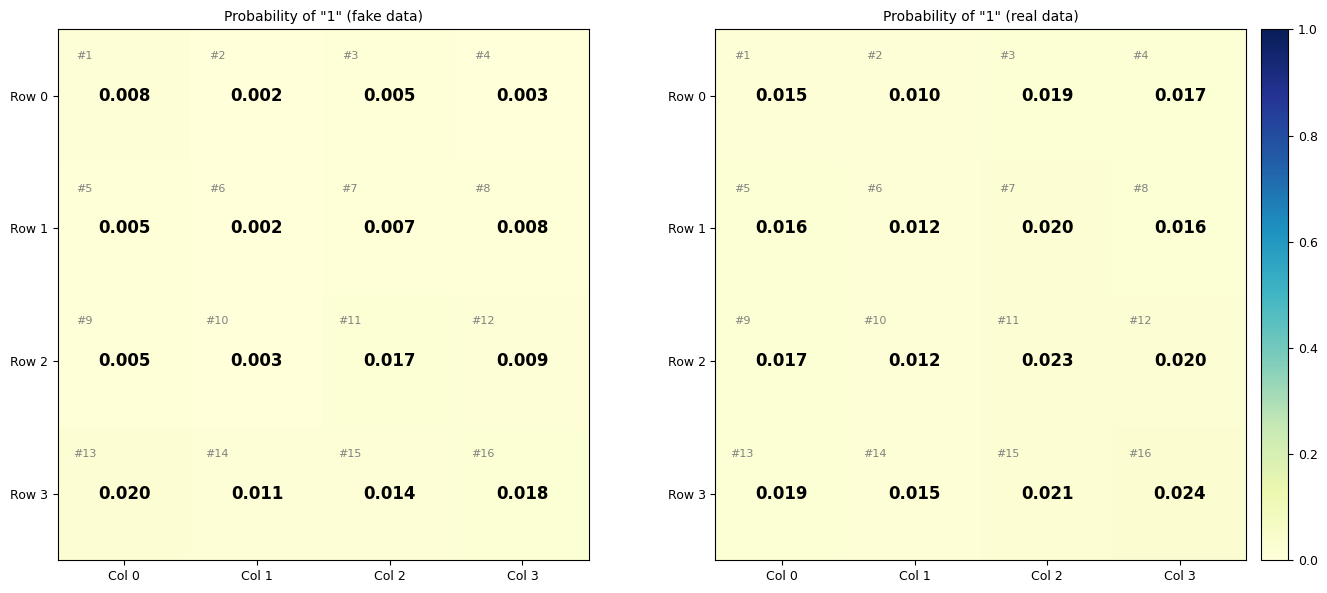

In [44]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1行2列のサブプロットを作成
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

data_list = [heatmap_data_fake, heatmap_data_real]
titles = ['Probability of "1" (fake data)', 'Probability of "1" (real data)']

for i, (ax, data, title) in enumerate(zip(axes, data_list, titles)):
    im = ax.imshow(data, cmap='YlGnBu', vmin=0, vmax=1)
    
    # テキスト表示（要素番号と確率）
    for r in range(4):
        for c in range(4):
            index = r * 4 + c + 1
            ax.text(c - 0.3, r - 0.3, f'#{index}', fontsize=8, color='gray', ha='center', va='center')
            ax.text(c, r, f'{data[r, c]:.3f}', fontsize=12, fontweight='bold', ha='center', va='center')
    
    ax.set_title(title)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'Col {j}' for j in range(4)])
    ax.set_yticks(range(4))
    ax.set_yticklabels([f'Row {k}' for k in range(4)])

    # カラーバーの調整：右側のグラフ(i=1)のときだけ横に付け足す
    if i == 1:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.15) # 右側に5%の幅で追加
        fig.colorbar(im, cax=cax)

# レイアウトの自動調整（重なりを防止）
plt.tight_layout()
plt.show()

In [45]:
import scipy.stats

# 0除算やlog(0)を防ぐための微小値
eps = 1e-10
p1 = np.clip(probabilities, eps, 1 - eps)
p2 = np.clip(probabilities2, eps, 1 - eps)

# 1. Mean Squared Error (MSE)
mse = np.mean((p1 - p2)**2)
print(f"Mean Squared Error (MSE): {mse:.6f}")

# 2. Mean Absolute Error (MAE)
mae = np.mean(np.abs(p1 - p2))
print(f"Mean Absolute Error (MAE): {mae:.6f}")

# 3. KL Divergence (各要素を独立なベルヌーイ分布とみなした場合の合計値)
kl_bernoulli = np.sum(p1 * np.log(p1 / p2) + (1 - p1) * np.log((1 - p1) / (1 - p2)))
print(f"KL Divergence (Independent Bernoullis): {kl_bernoulli:.6f}")

# 4. KL Divergence (全体を1つの確率分布として和が1になるよう正規化した場合)
kl_categorical = scipy.stats.entropy(p1, p2)
print(f"KL Divergence (Normalized Categorical): {kl_categorical:.6f}")


Mean Squared Error (MSE): 0.000094
Mean Absolute Error (MAE): 0.008962
KL Divergence (Independent Bernoullis): 0.063832
KL Divergence (Normalized Categorical): 0.134265
